In [ ]:
!pip install bayesian-optimization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from plotly import tools
from sklearn.model_selection import train_test_split
from bayes_opt import BayesianOptimization
import xgboost as xgb
from xgboost import XGBRegressor
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import datetime as dt
from math import sqrt
from sklearn.metrics import r2_score , mean_absolute_error , mean_absolute_percentage_error , mean_squared_error
import pickle
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/Foreign_Exchange_Rates.xls")
df.head()

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,0,03-01-2000,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,...,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97,NaN
1,1,04-01-2000,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13,NaN
2,2,05-01-2000,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,...,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1,NaN
3,3,06-01-2000,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62,NaN
4,4,07-01-2000,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3,NaN


##Pre processing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Unnamed: 0                                 5217 non-null   int64  
 1   Time Serie                                 5217 non-null   object 
 2   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5217 non-null   object 
 3   EURO AREA - EURO/US$                       5217 non-null   object 
 4   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5217 non-null   object 
 5   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   object 
 6   BRAZIL - REAL/US$                          5217 non-null   object 
 7   CANADA - CANADIAN DOLLAR/US$               5217 non-null   object 
 8   CHINA - YUAN/US$                           5217 non-null   object 
 9   HONG KONG - HONG KONG DOLLAR/US$           5217 non-null   object 
 10  INDIA - INDIAN RUPEE/US$

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.columns = df.columns.str.strip()
df['Time Serie'] = pd.to_datetime(df['Time Serie'], format = '%d-%m-%Y')

In [ ]:
df = df.set_index('Time Serie')
df = df.sort_index()

In [ ]:
df = df.replace('ND', pd.NA) #removing non numeric values
df = df.apply(pd.to_numeric)

In [ ]:
# Drop the 'Unnamed: 0' and 'Unnamed: 24' columns as they are not relevant
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 24'], errors='ignore')
display(df.head())

,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,KOREA - WON/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
Time Serie,,,,,,,,,,,,,,,,,,,,,
2000-01-03,1.5172,0.9847,1.9033,0.6146,1.8050,1.4465,8.2798,7.7765,43.55,1128.0,...,1.6563,7.3290,101.70,3.8,7.964,8.4430,72.30,1.5808,31.38,36.97
2000-01-04,1.5239,0.9700,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,43.55,1122.5,...,1.6535,7.2180,103.09,3.8,7.934,8.3600,72.65,1.5565,30.60,37.13
2000-01-05,1.5267,0.9676,1.9339,0.6092,1.8560,1.4518,8.2798,7.7780,43.55,1135.0,...,1.6560,7.2080,103.77,3.8,7.935,8.3530,72.95,1.5526,30.80,37.10
2000-01-06,1.5291,0.9686,1.9436,0.6070,1.8400,1.4571,8.2797,7.7785,43.55,1146.5,...,1.6655,7.2125,105.19,3.8,7.940,8.3675,72.95,1.5540,31.75,37.62
2000-01-07,1.5272,0.9714,1.9380,0.6104,1.8310,1.4505,8.2794,7.7783,43.55,1138.0,...,1.6625,7.2285,105.17,3.8,7.966,8.4150,73.15,1.5623,30.85,37.30


In [ ]:
df = df.asfreq('D')
df = df.fillna(method = 'ffill') #forward fill

In [ ]:
#df = df.diff().iloc[1:]

In [ ]:
df.isnull().sum()

,0
AUSTRALIA - AUSTRALIAN DOLLAR/US$,0
EURO AREA - EURO/US$,0
NEW ZEALAND - NEW ZELAND DOLLAR/US$,0
UNITED KINGDOM - UNITED KINGDOM POUND/US$,0
BRAZIL - REAL/US$,0
CANADA - CANADIAN DOLLAR/US$,0
CHINA - YUAN/US$,0
HONG KONG - HONG KONG DOLLAR/US$,0
INDIA - INDIAN RUPEE/US$,0
KOREA - WON/US$,0


##EDA

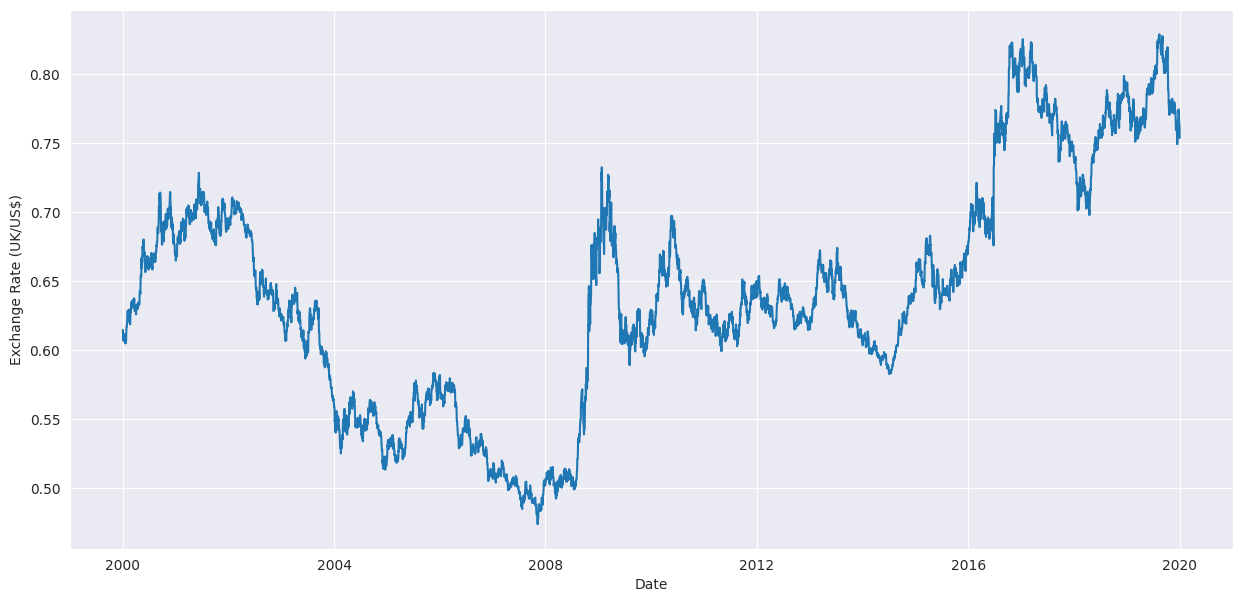

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['UNITED KINGDOM - UNITED KINGDOM POUND/US$'])
plt.xlabel('Date')
plt.ylabel('Exchange Rate (UK/US$)')
plt.grid(True)
plt.show()

In [ ]:
df_week = df.resample('W').mean()
print('Count of The Weekly Data Frame : ',df_week.shape[0])

Count of The Weekly Data Frame :  1044


In [ ]:
df_week.head()

,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,KOREA - WON/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
Time Serie,,,,,,,,,,,,,,,,,,,,,
2000-01-09,1.525500,0.972157,1.931229,0.610414,1.833500,1.451243,8.279629,7.777914,43.550000,1135.142857,...,1.659829,7.236143,104.180000,3.8,7.953000,8.395500,72.900000,1.561543,31.011429,37.245714
2000-01-16,1.508843,0.978971,1.923471,0.609429,1.815071,1.452486,8.279629,7.778743,43.564286,1133.642857,...,1.670771,7.285286,105.828571,3.8,7.986214,8.443286,73.342857,1.578729,30.821429,37.508571
2000-01-23,1.506414,0.988743,1.945557,0.607529,1.787243,1.446714,8.279514,7.779257,43.592857,1128.000000,...,1.677643,7.361286,105.295714,3.8,7.997286,8.482286,73.178571,1.595514,30.852857,37.331429
2000-01-30,1.558471,1.010900,2.008171,0.611957,1.782714,1.442900,8.278329,7.780071,43.634286,1123.900000,...,1.698171,7.521071,106.228571,3.8,8.155286,8.664357,73.200000,1.629271,30.804286,37.494286
2000-02-06,1.576986,1.023071,2.028329,0.624114,1.782286,1.446257,8.278129,7.780914,43.645714,1128.928571,...,1.695714,7.613857,107.705714,3.8,8.253000,8.693857,73.500000,1.645743,30.928571,37.564286


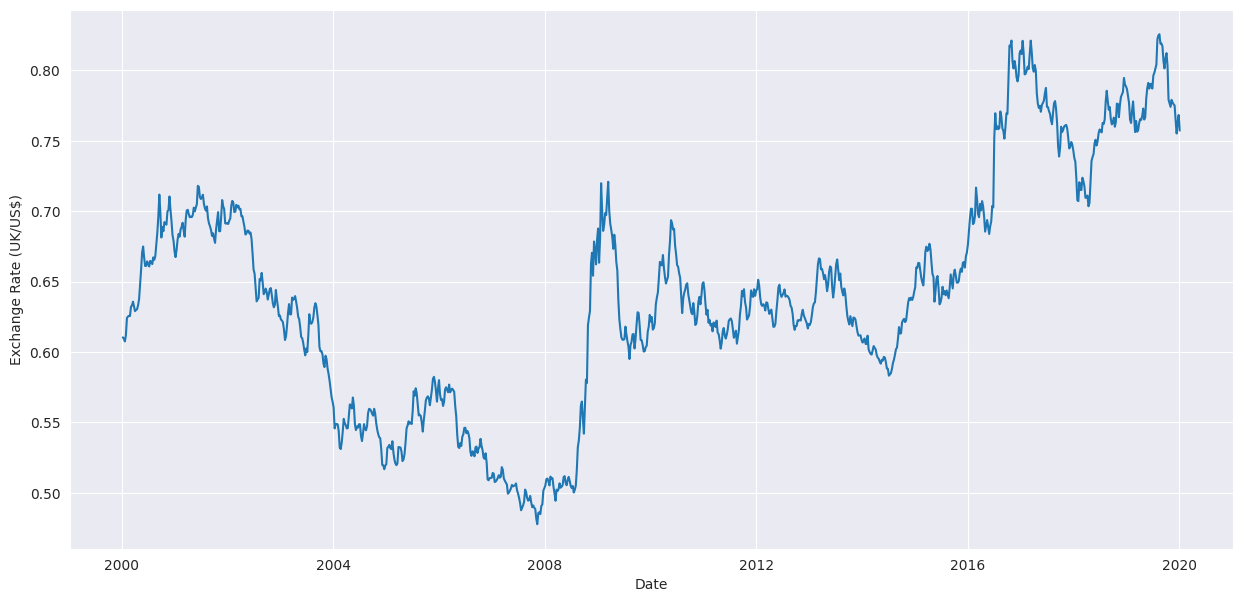

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(df_week.index, df_week['UNITED KINGDOM - UNITED KINGDOM POUND/US$'])
plt.xlabel('Date')
plt.ylabel('Exchange Rate (UK/US$)')
plt.grid(True)
plt.show()

In [ ]:
df_month = df.resample('M').mean()
print('Count of The Monthly Data Frame : ',df_month.shape[0])

Count of The Monthly Data Frame :  240


In [ ]:
df_month.head()

,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,KOREA - WON/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
Time Serie,,,,,,,,,,,,,,,,,,,,,
2000-01-31,1.526259,0.988976,1.954414,0.610114,1.804541,1.448452,8.279221,7.779066,43.587586,1129.958621,...,1.677445,7.360672,105.450345,3.8,8.032534,8.507345,73.167241,1.593272,30.868276,37.400345
2000-02-29,1.593841,1.017755,2.038862,0.625759,1.775483,1.450869,8.278152,7.781586,43.655862,1129.169310,...,1.702434,7.578803,109.497586,3.8,8.245086,8.652017,73.548966,1.635517,30.788621,37.766207
2000-03-31,1.641535,1.036171,2.041745,0.632890,1.741055,1.460981,8.278597,7.784661,43.641290,1116.463871,...,1.715313,7.716455,106.448710,3.8,8.403900,8.696468,73.822581,1.662206,30.723710,37.913548
2000-04-30,1.678017,1.059040,2.018300,0.632427,1.770283,1.468897,8.279257,7.788007,43.687800,1109.726667,...,1.709160,7.889807,105.554000,3.8,8.624560,8.747743,74.121000,1.666640,30.525833,37.980833
2000-05-31,1.728939,1.102671,2.127190,0.663681,1.829177,1.496216,8.278016,7.790810,44.082903,1120.490323,...,1.728597,8.222523,108.158387,3.8,9.046435,9.089348,74.894194,1.716729,30.773226,38.950323


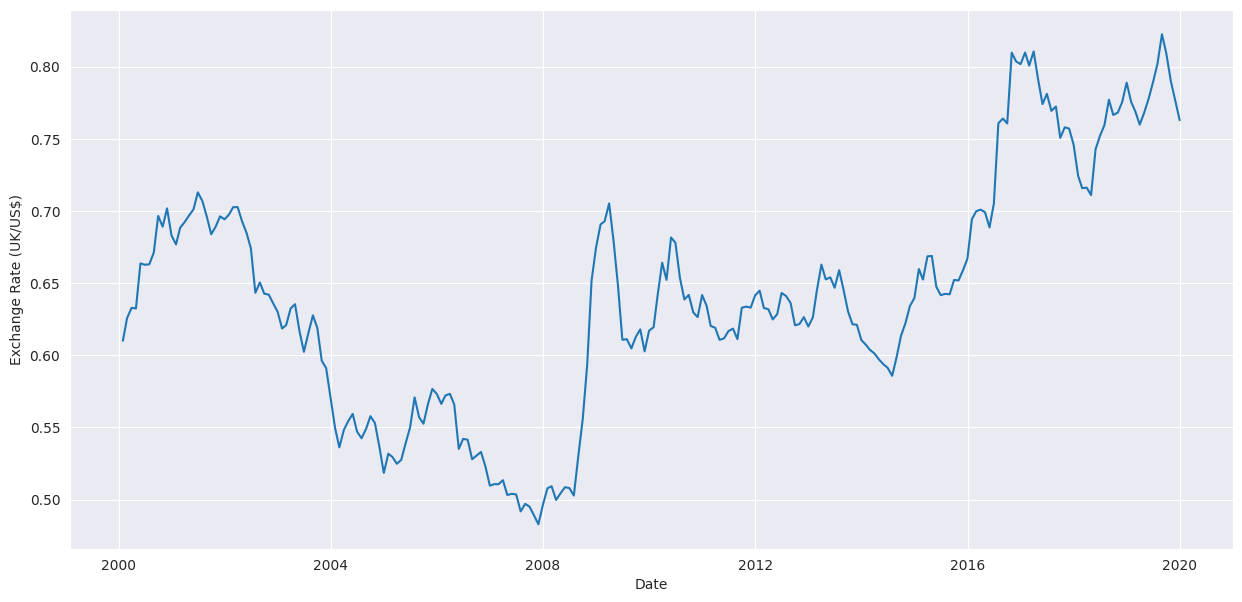

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(df_month.index, df_month['UNITED KINGDOM - UNITED KINGDOM POUND/US$'])
plt.xlabel('Date')
plt.ylabel('Exchange Rate (UK/US$)')
plt.grid(True)
plt.show()

In [ ]:
df_year = df.resample('Y').mean()
print('Count of The Yearly Data Frame : ',df_year.shape[0])

Count of The Yearly Data Frame :  20


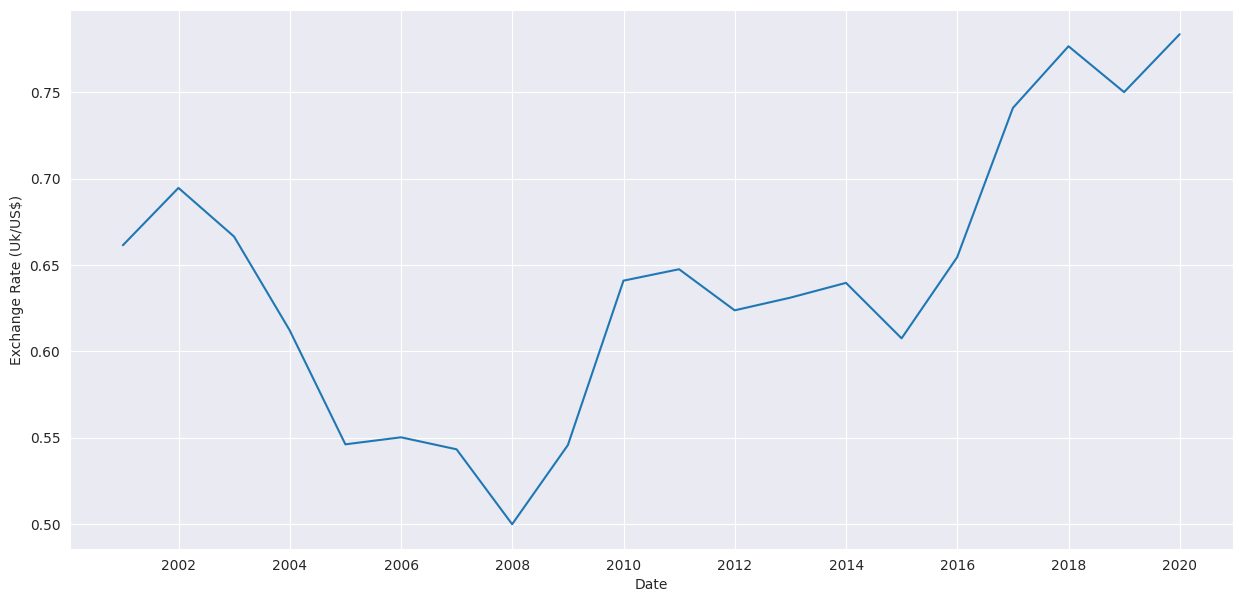

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(df_year.index, df_year['UNITED KINGDOM - UNITED KINGDOM POUND/US$'])
plt.xlabel('Date')
plt.ylabel('Exchange Rate (Uk/US$)')
plt.grid(True)
plt.show()

In [ ]:
df_year.head()

,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,KOREA - WON/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
Time Serie,,,,,,,,,,,,,,,,,,,,,
2000-12-31,1.727738,1.086215,2.205385,0.661357,1.831127,1.485711,8.278413,7.792439,45.010973,1131.476044,...,1.724940,8.094646,107.858571,3.800001,8.811888,9.176332,77.002335,1.689985,31.265761,40.225588
2001-12-31,1.935242,1.117769,2.380559,0.694569,2.354867,1.549056,8.277010,7.799657,47.233644,1291.723479,...,1.792612,8.330309,121.547753,3.800007,8.992878,10.340097,89.615411,1.688304,33.834515,44.521595
2002-12-31,1.840787,1.060702,2.160091,0.666402,2.923758,1.570219,8.277010,7.799596,48.620247,1249.990986,...,1.790344,7.882737,125.171699,3.800018,7.979523,9.717737,95.768795,1.556075,34.538110,43.025272
2003-12-31,1.540615,0.885033,1.722194,0.612150,3.075128,1.400592,8.277162,7.787287,46.588466,1191.841370,...,1.742721,6.576951,115.919836,3.800000,7.075938,8.077499,96.534767,1.344922,34.402605,41.549753
2004-12-31,1.359905,0.804928,1.508484,0.546076,2.925743,1.301035,8.276792,7.788737,45.274508,1145.952186,...,1.690177,5.989030,108.137486,3.800000,6.740037,7.347459,101.236516,1.242755,33.381672,40.269891


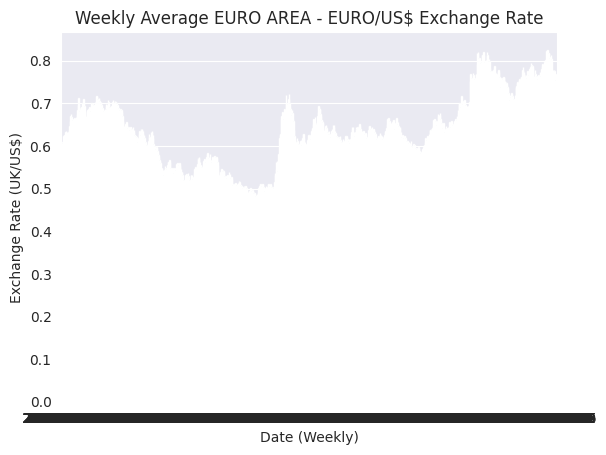

In [ ]:
sns.barplot(x=df_week.index, y=df_week['UNITED KINGDOM - UNITED KINGDOM POUND/US$'])
plt.xlabel('Date (Weekly)')
plt.ylabel('Exchange Rate (UK/US$)')
plt.title('Weekly Average EURO AREA - EURO/US$ Exchange Rate')
plt.show()

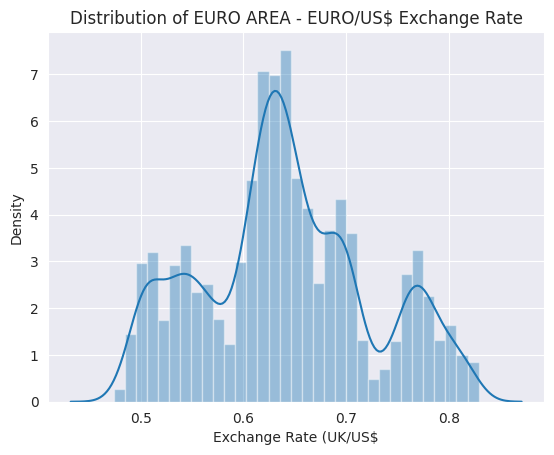

In [ ]:
sns.distplot(df['UNITED KINGDOM - UNITED KINGDOM POUND/US$'])
plt.xlabel('Exchange Rate (UK/US$')
plt.title('Distribution of EURO AREA - EURO/US$ Exchange Rate')
plt.show()

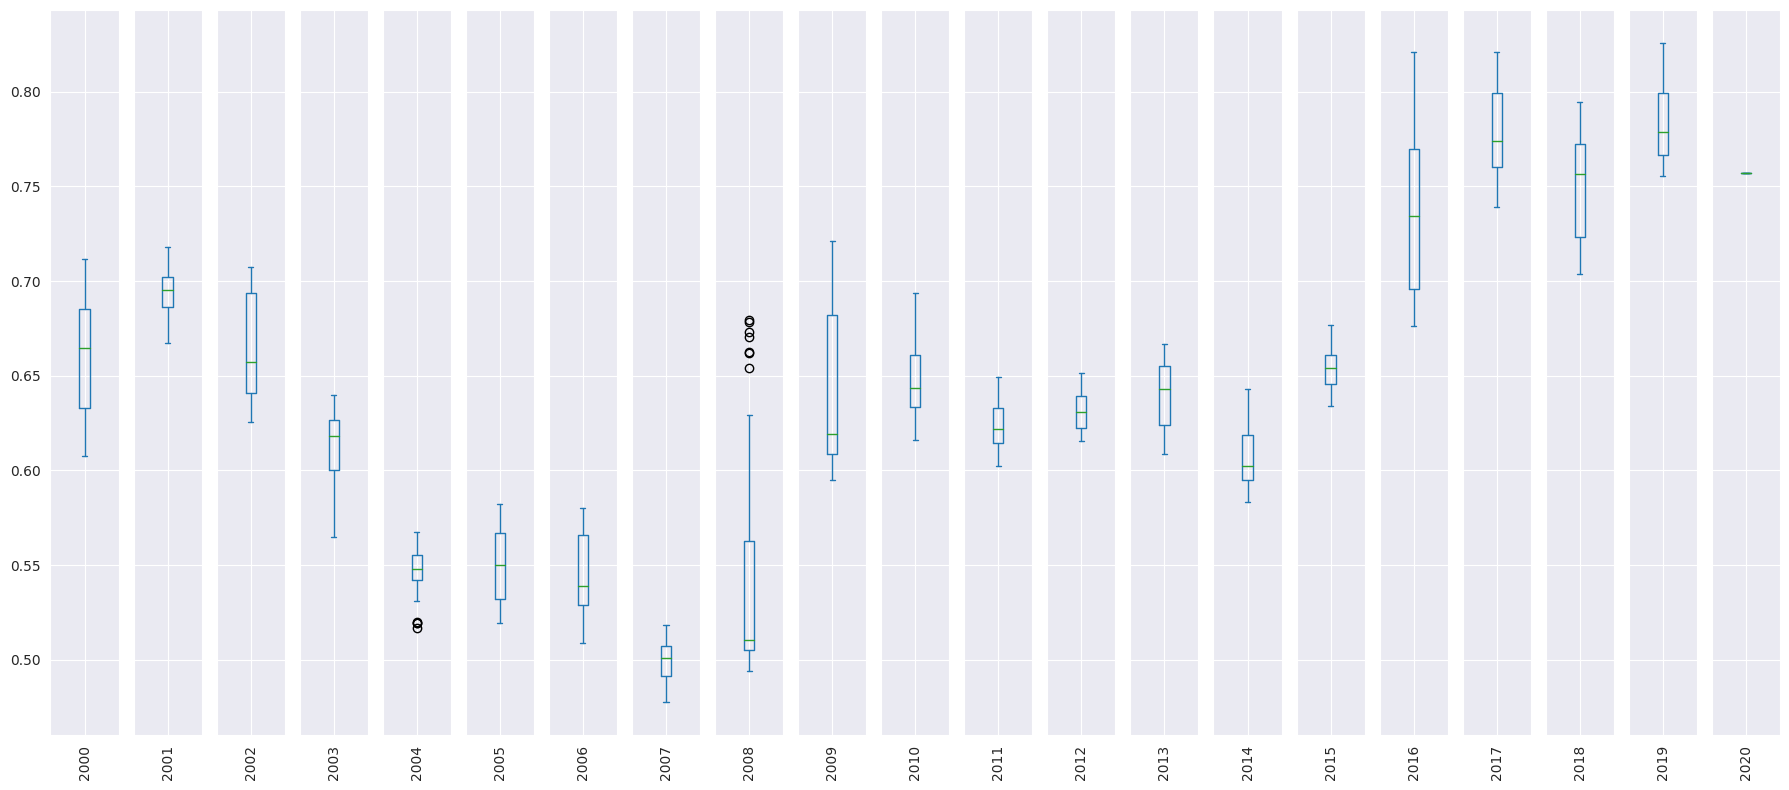

In [ ]:
box1 = df_week.groupby(df_week.index.year)

years = list(np.unique(df_week.index.year))

fig, ax = plt.subplots(1, len(years), figsize=(18, 8), sharey=True)
for i, year in enumerate(years):
    X = box1.get_group(year)
    # subplots=True,layout=(1,len(A)),figsize=(18,8),use_index = True,
    X.plot(y='UNITED KINGDOM - UNITED KINGDOM POUND/US$',
           kind='box',
           ax=ax[i],
           label=year,
           rot=90,
           sharey=True)
    plt.tight_layout()
plt.show()

### Data Splitting (Time-Based)

In [ ]:
# Add time-based features to the original DataFrame
df['year'] = df.index.year
df['month'] = df.index.month
df['day_of_week'] = df.index.dayofweek
df['day_of_year'] = df.index.dayofyear

display(df.head())

,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,KOREA - WON/US$,...,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,year,month,day_of_week,day_of_year
Time Serie,,,,,,,,,,,,,,,,,,,,,
2000-01-03,1.5172,0.9847,1.9033,0.6146,1.8050,1.4465,8.2798,7.7765,43.55,1128.0,...,7.964,8.4430,72.30,1.5808,31.38,36.97,2000,1,0,3
2000-01-04,1.5239,0.9700,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,43.55,1122.5,...,7.934,8.3600,72.65,1.5565,30.60,37.13,2000,1,1,4
2000-01-05,1.5267,0.9676,1.9339,0.6092,1.8560,1.4518,8.2798,7.7780,43.55,1135.0,...,7.935,8.3530,72.95,1.5526,30.80,37.10,2000,1,2,5
2000-01-06,1.5291,0.9686,1.9436,0.6070,1.8400,1.4571,8.2797,7.7785,43.55,1146.5,...,7.940,8.3675,72.95,1.5540,31.75,37.62,2000,1,3,6
2000-01-07,1.5272,0.9714,1.9380,0.6104,1.8310,1.4505,8.2794,7.7783,43.55,1138.0,...,7.966,8.4150,73.15,1.5623,30.85,37.30,2000,1,4,7


In [ ]:
#  a new DataFrame for feature engineering to avoid modifying the original 'df' directly for these features
df_fe = df.copy()

target_column  = 'UNITED KINGDOM - UNITED KINGDOM POUND/US$'

# lag features
df_fe[target_column + '_Lag1'] = df_fe[target_column].shift(1)
df_fe[target_column + '_Lag7'] = df_fe[target_column].shift(7)
df_fe[target_column + '_Lag30'] = df_fe[target_column].shift(30)

# rolling mean features
df_fe[target_column + '_RollingMean7'] = df_fe[target_column].rolling(window=7).mean()
df_fe[target_column + '_RollingMean30'] = df_fe[target_column].rolling(window=30).mean()
df_fe[target_column + '_RollingMean90'] = df_fe[target_column].rolling(window=90).mean()

# rolling std features
df_fe[target_column + '_RollingStd7'] = df_fe[target_column].rolling(window=7).std()
df_fe[target_column + '_RollingStd30'] = df_fe[target_column].rolling(window=30).std()

# Drop rows with NaN values introduced by lag and rolling features
df_fe.dropna(inplace=True)

display(df_fe.head())

,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,KOREA - WON/US$,...,day_of_week,day_of_year,UNITED KINGDOM - UNITED KINGDOM POUND/US$_Lag1,UNITED KINGDOM - UNITED KINGDOM POUND/US$_Lag7,UNITED KINGDOM - UNITED KINGDOM POUND/US$_Lag30,UNITED KINGDOM - UNITED KINGDOM POUND/US$_RollingMean7,UNITED KINGDOM - UNITED KINGDOM POUND/US$_RollingMean30,UNITED KINGDOM - UNITED KINGDOM POUND/US$_RollingMean90,UNITED KINGDOM - UNITED KINGDOM POUND/US$_RollingStd7,UNITED KINGDOM - UNITED KINGDOM POUND/US$_RollingStd30
Time Serie,,,,,,,,,,,,,,,,,,,,,
2000-04-01,1.6496,1.0445,2.0161,0.6281,1.742,1.4538,8.2787,7.7867,43.650,1105.5,...,5,92,0.6281,0.6285,0.6343,0.629086,0.632747,0.623200,0.001135,0.003069
2000-04-02,1.6496,1.0445,2.0161,0.6281,1.742,1.4538,8.2787,7.7867,43.650,1105.5,...,6,93,0.6281,0.6285,0.6325,0.629029,0.632600,0.623350,0.001179,0.003184
2000-04-03,1.6466,1.0460,2.0008,0.6258,1.742,1.4548,8.2786,7.7868,43.632,1113.0,...,0,94,0.6281,0.6307,0.6325,0.628329,0.632377,0.623516,0.001445,0.003418
2000-04-04,1.6578,1.0430,1.9972,0.6264,1.745,1.4531,8.2791,7.7863,43.650,1114.0,...,1,95,0.6258,0.6300,0.6325,0.627814,0.632173,0.623707,0.001391,0.003587
2000-04-05,1.6521,1.0366,1.9869,0.6289,1.755,1.4548,8.2795,7.7864,43.680,1115.5,...,2,96,0.6264,0.6301,0.6356,0.627643,0.631950,0.623950,0.001107,0.003575


In [ ]:
target_column  = 'UNITED KINGDOM - UNITED KINGDOM POUND/US$'
X = df_fe.drop(columns=[target_column])
y = df_fe[target_column]

# Split data based on time
X_train, X_test = X[:-30], X[-30:]
y_train, y_test = y[:-30], y[-30:]


print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")

Training data shape: (7184, 33), (7184,)
Testing data shape: (30, 33), (30,)


In [ ]:
train = xgb.DMatrix(X_train, label= y_train)
test = xgb.DMatrix(X_test)

In [ ]:
def xgb_evaluate(max_depth, gamma, colsample_bytree):
    params = {'eval_metric': 'rmse',
              'max_depth': int(max_depth),
              'subsample': 0.8,
              'eta': 0.1,
              'gamma': gamma,
              'colsample_bytree': colsample_bytree}

    cv_result = xgb.cv(params, train, num_boost_round=250, nfold=3)
    return -1.0 * cv_result['test-rmse-mean'].iloc[-1]

### XGBoost Model Training

In [ ]:
xgb_bo = BayesianOptimization(xgb_evaluate, {'max_depth': (3, 7),
                                             'gamma': (0, 1),
                                             'colsample_bytree': (0.3, 0.9)})
xgb_bo.maximize(init_points=10, n_iter=15)

print("XGBoost model trained successfully!")

|   iter    |  target   | max_depth |   gamma   | colsam... |
-------------------------------------------------------------
| 1         | -0.012907 | 6.2052196 | 0.2437327 | 0.4481311 |
| 2         | -0.022271 | 4.7305865 | 0.9678724 | 0.7042582 |
| 3         | -0.008816 | 5.6524236 | 0.0763709 | 0.4073427 |
| 4         | -0.017342 | 5.5491193 | 0.5544917 | 0.7759454 |
| 5         | -0.020719 | 6.6587552 | 0.7876308 | 0.6764660 |
| 6         | -0.021846 | 5.4274687 | 0.8803406 | 0.7863188 |
| 7         | -0.018304 | 3.3498201 | 0.6222388 | 0.6683292 |
| 8         | -0.013098 | 5.8111168 | 0.2946260 | 0.7808488 |
| 9         | -0.015807 | 5.2114772 | 0.4585964 | 0.8222673 |
| 10        | -0.007179 | 3.8354211 | 0.0364307 | 0.4287682 |
| 11        | -0.003384 | 4.5162040 | 0.0       | 0.3       |
| 12        | -0.003141 | 4.3838085 | 0.0       | 0.8020313 |
| 13        | -0.003134 | 4.6902619 | 0.0       | 0.6153485 |
| 14        | -0.003200 | 4.3949857 | 0.0       | 0.5531223 |
| 15    

### Model Evaluation

In [ ]:
params = xgb_bo.max['params']
params['max_depth'] = int(round(params['max_depth']))

model = xgb.train(params, train, num_boost_round = 200)

In [ ]:
predictions = model.predict(test)
predictions

array([0.77493155, 0.7722375 , 0.7728769 , 0.76669914, 0.7631539 ,
       0.7638962 , 0.7638906 , 0.7656071 , 0.76051676, 0.7608025 ,
       0.75933844, 0.76876354, 0.7596014 , 0.7610115 , 0.76033115,
       0.7585151 , 0.7664978 , 0.76460445, 0.76534414, 0.7650563 ,
       0.76673883, 0.7699679 , 0.77325505, 0.77326477, 0.7726964 ,
       0.7728149 , 0.76955503, 0.77021146, 0.76538336, 0.7666706 ],
      dtype=float32)

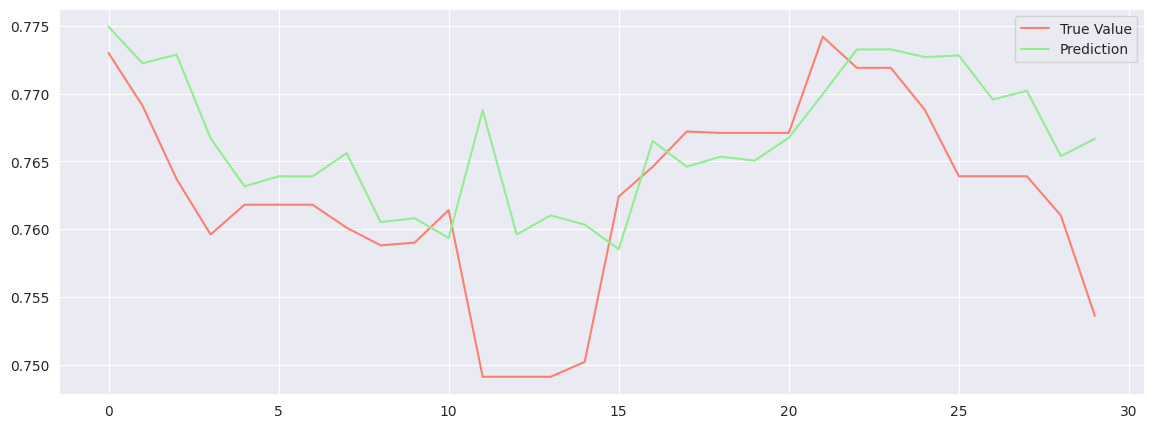

In [ ]:
y_val = y_test
plt.figure(figsize=(14,5))
sns.set_style('darkgrid')
plt.plot(np.arange(len(y_val)), y_val, color='salmon');
plt.plot(np.arange(len(y_val)), predictions, color='lightgreen');
plt.legend(['True Value', 'Prediction']);

In [ ]:
xgb_mae = mean_absolute_error(y_val, predictions)#
xgb_mse = mean_squared_error(y_val, predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_val, predictions))
xgb_error_rate = abs(((y_val - predictions) / y_val).mean()) * 100


print('Mean Absolute Error:   ', xgb_mae)
print('Mean Squared Error:   ', xgb_mse)
print('Root Mean Squared Error:   ', xgb_rmse)
print('Mean Absolute Percentage Error:', round(xgb_error_rate,2), '%')
print('R2-SCORE: ', r2_score(y_val, predictions))

Mean Absolute Error:    0.005063465572992946
Mean Squared Error:    4.5065833624005e-05
Root Mean Squared Error:    0.006713109087748016
Mean Absolute Percentage Error: 0.52 %
R2-SCORE:  0.04695993723343439
